In [36]:
import pandas as pd
import numpy as np
import plotly.express as px
import pickle
import re
import string
import emoji
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.pipeline import Pipeline as ImbPipeline
import multiprocessing
import concurrent.futures
from tqdm.notebook import tqdm
from joblib import Parallel, delayed


import deepcut
from pythainlp.tokenize import word_tokenize
from pythainlp.util import normalize
from pythainlp.spell import correct
from pythainlp.corpus.common import thai_stopwords
import fasttext
import fasttext.util

In [18]:
# fasttext.util.download_model('th', if_exists='ignore')
ft = fasttext.load_model('./semantic_search/cc.th.300.bin') 

In [3]:
FINE_TUNED_DIR = '../../pretained_or_finetune-models'
REVIEWS_DATASET_DIR = '../dataset/reviews'
UTILS_DIR = '../../utils'

In [4]:
tourism_reviews_en = pd.read_parquet(f"{REVIEWS_DATASET_DIR}/TripAdvisor_reviews_TH.parquet")

columns_to_use = ['helpful_votes', 'location_id', 'review_id', 'review',
                  'review_subject', 'trip_type', 'rating',
                  'location_name', 'province', 'place_id', 'emotion', 'cleaned_review']
columns_to_train = ['review_id', 'location_id', 'review_text', 'rating']
review_df = tourism_reviews_en[columns_to_train]

In [5]:
review_df.describe()

,review_id,location_id,rating
count,7.170000e+03,7.170000e+03,7170.000000
mean,6.063747e+08,6.112365e+06,4.369177
std,1.741121e+08,4.311252e+06,0.752342
min,1.322792e+08,3.110380e+05,1.000000
25%,4.608988e+08,2.706887e+06,4.000000
50%,6.376879e+08,5.990445e+06,5.000000
75%,7.409087e+08,8.654056e+06,5.000000
max,9.961066e+08,2.700068e+07,5.000000


In [6]:
review_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7170 entries, 0 to 7169
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   review_id    7170 non-null   int64 
 1   location_id  7170 non-null   int64 
 2   review_text  7170 non-null   object
 3   rating       7170 non-null   int64 
dtypes: int64(3), object(1)
memory usage: 224.2+ KB


In [14]:
review_df

,review_id,location_id,review_text,rating
0,555329702,456633,การบริการของพนักงานดี ภายในตกแต่งได้สวยงาม และ...,4
1,543783369,456633,เป็นพิพิธภัณฑ์ที่ให้ข้อมูลเกี่ยวกับฝิ่นผูกเรื่...,5
2,349537639,456633,หอฝิ่นเป็นสถานที่ที่ควรไปชมสักครั้งหนึ่ง ค่าเข...,4
3,347878221,456633,เป็นพิพิธภัณฑ์ที่รวบรวมทุกสิ่งทุกอย่างที่เกี่ย...,4
4,319533650,456633,เราเข้าไปเยี่ยมชมพิพิธภัณฑ์หอฟิ่นเป็นครั้งแรกว...,5
...,...,...,...,...
7165,821852808,23744675,บรรยากาศที่สะพานปลา อ่าวเจ้าหลาวยามเย็นสวยมากๆ...,4
7166,763005073,10266462,เดินมาเรื่อยๆก็ถึงวัดบูรพาราม Ubon ที่ถือเป็นว...,3
7167,398492373,10266462,เป็นอีกวัดหนึ่งในจังหวัดอุบลราชธานีที่มีความสว...,3
7168,364357012,10266462,วัดบูรพาแห่งนี้จะหายากสักหน่อยเพราะอยู่ออกห่าง...,3


In [37]:
STOP_WORDS = set(thai_stopwords())

def clean_text(text):
    """Cleans and tokenizes Thai text using Deepcut"""
    try:
        text = text.lower()  # Convert to lowercase
        text = re.sub(r'\d+', '', text)  # Remove numbers
        text = re.sub(r'[^ก-๙a-zA-Z\s]', '', text)  # Remove special characters
        text = normalize(text)  # Normalize Thai text
        text = emoji.demojize(text)  # Convert emojis to text descriptions
        text = ''.join([char for char in text if char not in string.punctuation])  # Remove punctuation
        
        # Use Deepcut for Tokenization
        tokens = deepcut.tokenize(text)
        
        # Remove stop words
        tokens = [word for word in tokens if word not in STOP_WORDS]

        return ' '.join(tokens)
    
    except Exception as e:
        print(f"Error processing text: {text} -> {e}")
        raise e  # Force stop the pool


def parallel_clean_texts(texts, num_workers=2):
    return Parallel(n_jobs=num_workers)(delayed(clean_text)(text) for text in tqdm(texts))

In [12]:
review_df['text_length'] = review_df['review_text'].apply(len)

# Create an interactive histogram using Plotly
fig = px.histogram(
    review_df, 
    x='text_length', 
    nbins=50,  # Adjust the number of bins
    title="Distribution of Review Text Lengths",
    labels={'text_length': 'Review Text Length'},
    opacity=0.7
)

# Update layout for better visualization
fig.update_layout(
    bargap=0.2, 
    xaxis_title="Review Text Length", 
    yaxis_title="Frequency", 
    template="plotly_white"
)

fig.show()

/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_2587/4276488930.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  review_df['text_length'] = review_df['review_text'].apply(len)


In [38]:
# Apply preprocessing to the review texts
# review_df['cleaned_review'] = review_df['review_text'].apply(advanced_clean_text)
# review_df['cleaned_review'] = review_df['review_text'].apply(clean_text)
review_df['cleaned_review'] = parallel_clean_texts(review_df['review_text'].tolist(), num_workers=2)


# 2. สร้าง Word Embeddings ด้วย Word2Vec
# word2vec_model = Word2Vec(sentences=review_df['cleaned_review'], vector_size=300, window=5, min_count=1, sg=1)  # ใช้ Skip-Gram
# sentences = [row.split() for row in review_df['cleaned_review']]
# word2vec_model = Word2Vec(sentences, vector_size=300, window=5, min_count=1, workers=4)  # เปลี่ยน vector_size เป็น 300



  0%|          | 0/7170 [00:00<?, ?it/s]

/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.p

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 164ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 56ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step e
12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step p
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/joblib/externals/loky/process_executor.py:752: UserWarning:

A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.



4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━

...

/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


6/6 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
22/22 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
7/7 ━━━━━━━━━

/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/keras/src/layers/core/embedding.py:90: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
/Users/ittichaiboonyarakthunya/Documents/WorkDir/developments/IS_Project/.venv/lib/python3.12/site-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


37/37 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 186ms/step
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
4/4 

/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_2587/1039476501.py:4: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
# review_df.to_parquet("./SVM_TH_Cleaned_Data.parquet", engine="pyarrow", compression="zstd")
review_df

,review_id,location_id,review_text,rating,text_length,cleaned_review
0,555329702,456633,การบริการของพนักงานดี ภายในตกแต่งได้สวยงาม และ...,4,125,บริการ พนักงาน ดี ตกแต่ง สวยงาม รู้ บรรย...
1,543783369,456633,เป็นพิพิธภัณฑ์ที่ให้ข้อมูลเกี่ยวกับฝิ่นผูกเรื่...,5,297,พิพิธภัณฑ์ ข้อมูล เกี่ยว ฝิ่น ผูก เรื่อง อารยธ...
2,349537639,456633,หอฝิ่นเป็นสถานที่ที่ควรไปชมสักครั้งหนึ่ง ค่าเข...,4,298,หอ ฝิ่น สถานที่ ชม สัก ค่า ชม คน ไทย บาท ...
3,347878221,456633,เป็นพิพิธภัณฑ์ที่รวบรวมทุกสิ่งทุกอย่างที่เกี่ย...,4,107,พิพิธภัณฑ์ รวบรวม ทุกสิ่งทุกอย่าง เกี่ยว ปลูกฝ...
4,319533650,456633,เราเข้าไปเยี่ยมชมพิพิธภัณฑ์หอฟิ่นเป็นครั้งแรกว...,5,243,เยี่ยมชม พิพิธภัณฑ์หอฟิ่น วิว รอบ หอ สวยงาม ค่...
...,...,...,...,...,...,...
7165,821852808,23744675,บรรยากาศที่สะพานปลา อ่าวเจ้าหลาวยามเย็นสวยมากๆ...,4,615,บรรยากาศ สะพานปลา อ่าวเจ้าหลาวยาม เย็น สวย ...
7166,763005073,10266462,เดินมาเรื่อยๆก็ถึงวัดบูรพาราม Ubon ที่ถือเป็นว...,3,176,เดิน วัดบูรพาราม ubon วัด ต้น กำเนิด สายวิ...
7167,398492373,10266462,เป็นอีกวัดหนึ่งในจังหวัดอุบลราชธานีที่มีความสว...,3,102,วัด จังหวัดอุบลราชธานี สวยงาม ตัวเมือง อุบล ...
7168,364357012,10266462,วัดบูรพาแห่งนี้จะหายากสักหน่อยเพราะอยู่ออกห่าง...,3,246,วัดบูรพา หา สัก ห่าง เมือง ทิศ ตะวัน วัด รู้...


In [40]:
def map_rating_to_sentiment(rating):
    if rating in [1, 2]:
        return 'negative'
    elif rating == 3:
        return 'neutral'
    elif rating in [4, 5]:
        return 'positive'

# Apply the mapping to your DataFrame
review_df['sentiment'] = review_df['rating'].apply(map_rating_to_sentiment)

/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_2587/3932828178.py:10: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [38]:
# Transform the text data using TF-IDF
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(review_df['cleaned_review']).toarray()

# Tokenize the cleaned reviews for Word2Vec
review_df['tokens'] = review_df['cleaned_review'].apply(lambda x: x.split())

# Train Word2Vec model on tokenized reviews
word2vec_model = Word2Vec(sentences=review_df['tokens'], vector_size=100, window=5, min_count=1, workers=4)


/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_60787/4243137019.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  review_df['tokens'] = review_df['cleaned_review'].apply(lambda x: x.split())


In [39]:
def compute_avg_word2vec(tokens, model):
    vector_size = model.vector_size
    avg_vector = np.zeros(vector_size)
    count = 0
    
    for word in tokens:
        if word in model.wv:
            avg_vector += model.wv[word]
            count += 1
    
    if count != 0:
        avg_vector /= count
    
    return avg_vector

In [40]:
# Compute Word2Vec embeddings for each review
review_df['word2vec_embedding'] = review_df['tokens'].apply(lambda x: compute_avg_word2vec(x, word2vec_model))

# Combine TF-IDF vectors with Word2Vec embeddings
X_combined = np.hstack((X_tfidf, np.vstack(review_df['word2vec_embedding'].values)))

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X_combined, review_df['sentiment'], test_size=0.2, random_state=42)


/var/folders/fk/449tdf_12hzd2r7ps4659q0m0000gn/T/ipykernel_60787/3766833753.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  review_df['word2vec_embedding'] = review_df['tokens'].apply(lambda x: compute_avg_word2vec(x, word2vec_model))


In [41]:
# Create a pipeline with SMOTE, Random Undersampling, and SVM with Class Weights
pipeline = ImbPipeline([
    ('smote', SMOTE(random_state=42)),  # Apply SMOTE to oversample minority classes
    ('undersample', RandomUnderSampler(random_state=42)),  # Apply Random Undersampling to balance the majority class
    ('scaler', StandardScaler()),  # Normalize features
    ('svm', SVC(kernel='linear', C=1.0, class_weight='balanced', random_state=42))  # SVM with class weights
])

In [42]:
# Train the model
# pipeline.fit(X_train, y_train)

In [43]:

# with open('../../models/SVN_model_sample.pkl', 'wb') as file:
#     pickle.dump(pipeline, file)
    
with open('../../models/SVN_model_sample.pkl', 'rb') as file:
    pipeline = pickle.load(file)

In [44]:
# Check the shapes of the resulting arrays
print(f"X_train shape: {X_train.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")


X_train shape: (4727, 16164)
y_train shape: (4727,)
X_test shape: (1182, 16164)
y_test shape: (1182,)


In [45]:
# Make predictions
y_pred = pipeline.predict(X_test)

# Evaluate the model
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['negative', 'neutral', 'positive']))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred, labels=['negative', 'neutral', 'positive'])
print("Confusion Matrix:")
print(conf_matrix)

Accuracy: 0.75
Classification Report:
              precision    recall  f1-score   support

    negative       0.46      0.40      0.42        91
     neutral       0.22      0.18      0.20       157
    positive       0.84      0.88      0.86       934

    accuracy                           0.75      1182
   macro avg       0.51      0.49      0.50      1182
weighted avg       0.73      0.75      0.74      1182

Confusion Matrix:
[[ 36  17  38]
 [ 15  29 113]
 [ 28  83 823]]


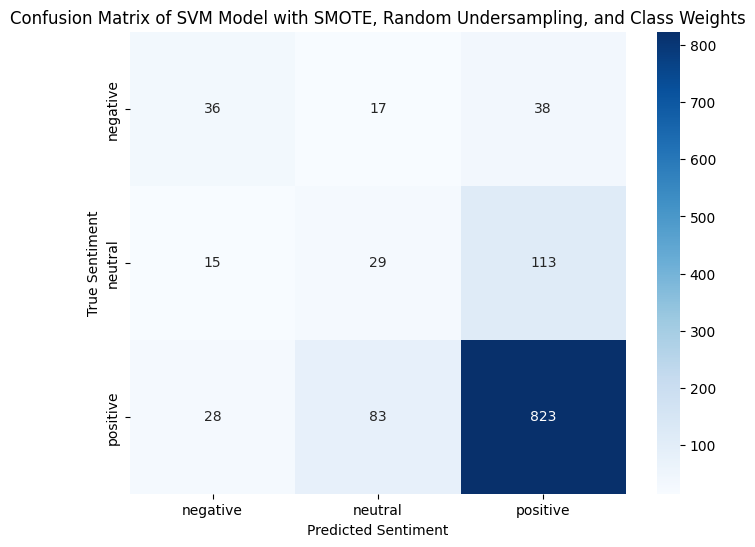

In [46]:
# Visualize the Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['negative', 'neutral', 'positive'], yticklabels=['negative', 'neutral', 'positive'])
plt.xlabel('Predicted Sentiment')
plt.ylabel('True Sentiment')
plt.title('Confusion Matrix of SVM Model with SMOTE, Random Undersampling, and Class Weights')
plt.show()

In [47]:
# Calculate precision, recall, and F1-score
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print(f'Precision: {precision:.4f}')
print(f'Recall: {recall:.4f}')
print(f'F1-Score: {f1:.4f}')

Precision: 0.7326
Recall: 0.7513
F1-Score: 0.7412


In [48]:
y_pred

array(['neutral', 'neutral', 'positive', ..., 'neutral', 'positive',
       'positive'], dtype=object)

In [49]:
y_test

3489    negative
4909    positive
1425    positive
4743     neutral
439     positive
          ...   
5333    positive
4310    positive
653     positive
429      neutral
1773    positive
Name: sentiment, Length: 1182, dtype: object

In [ ]:

predictions_df = pd.DataFrame({
    "place_id": review_df.loc[y_test.index, 'place_id'],
    "location_id": review_df.loc[y_test.index, 'location_id'],
    'review_text': review_df.loc[y_test.index, 'review'],  # Assuming X_test is a subset with a specific index
    'actual_sentiment': y_test,  # The actual sentiment labels
    'predicted_sentiment': y_pred  # The predicted sentiment labels
})

predictions_df.head(10)


,place_id,location_id,review_text,actual_sentiment,predicted_sentiment
3489,P03014167,15815967,While I should probably come back at a better ...,negative,neutral
4909,P03013134,1419900,Nice place Have Food Court KFC Lawson Bic C Se...,positive,neutral
1425,P03008087,4322482,Since I was born and grew up in Ceylon (Sri La...,positive,positive
4743,P03012239,3281227,This shrine is located in front of Central\nWo...,neutral,positive
439,P03006766,552562,Wat Suan Dok is just east of the Old City on S...,positive,positive
5490,P03013842,10595132,"Every old Thai city has its City Lake, Khon Ka...",positive,positive
1319,P03013536,7365833,"On every Saturday and Sunday from 17:00-22:00,...",positive,positive
1330,P03013536,10619214,This was a fantastic spot to not only stretch ...,positive,positive
4091,P03014635,9785391,"Took daughter, she seemed to have a fun time ...",positive,positive
296,P03018824,12899859,Cute elephant and nice people with lovely food...,positive,positive


In [54]:
predictions_df.to_csv("../prediction/SVN_Prediction.csv", index=False)